matplotlib 3.10.0
numpy 2.1.3
pandas 2.2.3
sklearn 1.8.0
torch 2.9.1+cu130
图像大小: (28, 28)
图像模式: L
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 13, 73, 0, 0, 1, 4, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 36, 136, 127, 62, 54, 0, 0, 0, 1, 3, 4, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 0, 102, 204, 176, 134, 144, 123, 23, 0, 0, 0, 0, 12, 10, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 155, 236, 207, 178, 107, 156, 161, 109, 64, 23, 77, 130, 72, 15, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141, 88, 172, 66, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196, 229, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 183,

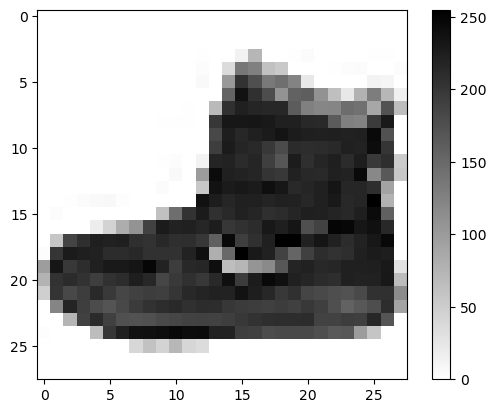

In [22]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline  
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm 
import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets
from torchvision.transforms import ToTensor
from torchvision import transforms

for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)
    
# 设置设备：如果有GPU则使用GPU，否则使用CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")


train_ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=None
)

test_ds = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=None
)

img, label = train_ds[0]

def show_img_content(img):
    from PIL import Image

    print("图像大小:", img.size)
    print("图像模式:", img.mode)

    if img.mode == 'L':
        pixel_values = list(img.getdata())
        print(pixel_values)
show_img_content(img)

def show_single_image(img_arr):
    plt.imshow(img_arr, cmap="binary") # 显示图片
    plt.colorbar() # 显示颜色条
    plt.show()

show_single_image(img)

训练集大小: 60000
测试集大小: 10000
类别数量: 10
类别标签: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


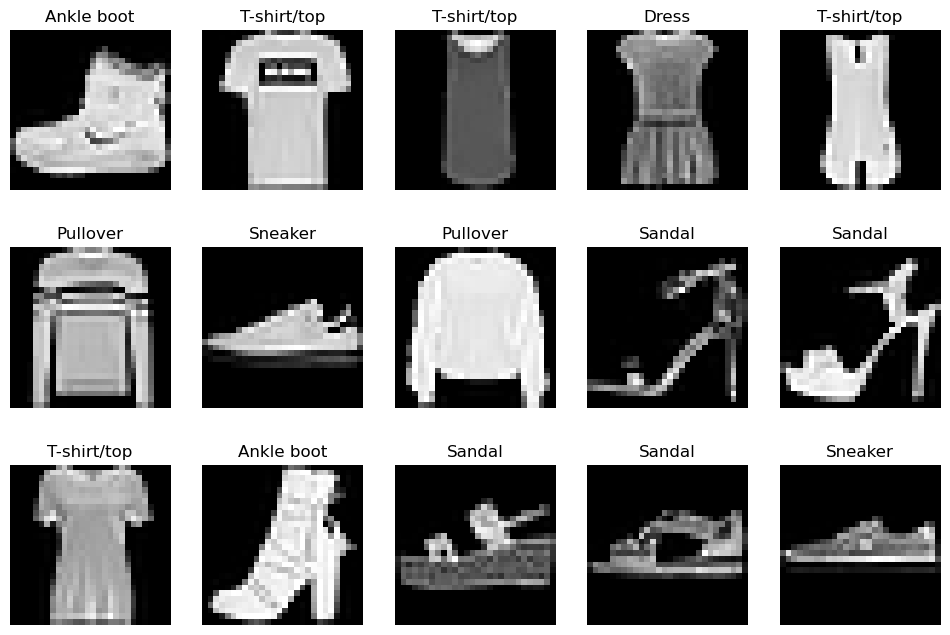

In [23]:
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print(f"训练集大小: {len(train_dataset)}")
print(f"测试集大小: {len(test_dataset)}")
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(f"类别数量: {len(class_names)}")
print(f"类别标签: {class_names}")
print(train_dataset.classes)

fig, axes = plt.subplots(3, 5, figsize=(12, 8))
for i in range(15):
    ax = axes[i//5, i%5]
    ax.imshow(train_dataset[i][0].squeeze(), cmap='gray')
    ax.set_title(class_names[train_dataset[i][1]])
    ax.axis('off')
plt.show()

In [24]:
batch_size = 128

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

print(f"训练集批次数量: {len(train_loader)}")
print(f"测试集批次数量: {len(test_loader)}")
print(f"每个批次样本数量: {batch_size}")

train_features, train_labels = next(iter(train_loader))
print(f"训练集第一个批次特征形状: {train_features.shape}")
print(f"训练集第一个批次标签形状: {train_labels.shape}")
print(f"训练集第一个批次标签: {train_labels}")

训练集批次数量: 469
测试集批次数量: 79
每个批次样本数量: 128
训练集第一个批次特征形状: torch.Size([128, 1, 28, 28])
训练集第一个批次标签形状: torch.Size([128])
训练集第一个批次标签: tensor([7, 3, 9, 2, 0, 2, 0, 6, 3, 2, 6, 5, 9, 0, 4, 8, 8, 3, 1, 8, 9, 9, 9, 8,
        0, 3, 4, 2, 4, 0, 2, 6, 0, 9, 6, 2, 5, 6, 6, 1, 6, 5, 0, 4, 6, 8, 1, 8,
        1, 3, 2, 1, 6, 3, 8, 6, 5, 2, 6, 3, 7, 7, 4, 8, 6, 0, 5, 9, 5, 8, 0, 4,
        0, 2, 6, 6, 5, 0, 9, 9, 6, 1, 5, 7, 5, 1, 1, 1, 6, 6, 7, 2, 4, 7, 1, 4,
        2, 7, 8, 3, 9, 5, 4, 4, 9, 0, 8, 8, 4, 0, 5, 1, 4, 3, 1, 7, 8, 9, 8, 3,
        0, 7, 6, 5, 7, 4, 6, 0])


In [25]:
#模型搭建
import torch.nn as nn

class TwoLayerNN(nn.Module):
    def __init__(self):
        super(TwoLayerNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 300)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(300, 100)
        self.relu = nn.ReLU()
        self.fc3 = nn.Linear(100, 10)
    
    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x
    
model = TwoLayerNN()
print(model)

TwoLayerNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=300, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=300, out_features=100, bias=True)
  (fc3): Linear(in_features=100, out_features=10, bias=True)
)


In [26]:
import torch

dummy_input = torch.randn(32, 1, 28, 28)
output = model(dummy_input)
print(f"Output shape: {output.shape}")

total_params = 0
for name, param in model.named_parameters():
    if param.requires_grad:
        num_params = param.numel()
        total_params += num_params
        print(f"{name}: {num_params}")
        
print(f"Total trainable parameters: {total_params}")


Output shape: torch.Size([32, 10])
fc1.weight: 235200
fc1.bias: 300
fc2.weight: 30000
fc2.bias: 100
fc3.weight: 1000
fc3.bias: 10
Total trainable parameters: 266610


In [27]:
#训练模型
from torch import cuda
import torch.nn as nn
import torch.optim as optim
import tqdm as tqdm

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

import wangdao_train_pre1 as wangdao_train

trainer = wangdao_train.Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=100
)

num_epochs = 10

trainer.train(num_epochs)

[Step 100] Val Loss: 0.5939 Val Acc: 0.7837
[Step 200] Val Loss: 0.5189 Val Acc: 0.8206
[Step 300] Val Loss: 0.5024 Val Acc: 0.8218
[Step 400] Val Loss: 0.4656 Val Acc: 0.8333
Epoch [1/10]  Train Loss: 0.5685  Train Acc: 0.8013
[Step 500] Val Loss: 0.4303 Val Acc: 0.8472
[Step 600] Val Loss: 0.4196 Val Acc: 0.8513
[Step 700] Val Loss: 0.4276 Val Acc: 0.8477
[Step 800] Val Loss: 0.4030 Val Acc: 0.8586
[Step 900] Val Loss: 0.4058 Val Acc: 0.8520
Epoch [2/10]  Train Loss: 0.3887  Train Acc: 0.8606
[Step 1000] Val Loss: 0.4220 Val Acc: 0.8485
[Step 1100] Val Loss: 0.3945 Val Acc: 0.8576
[Step 1200] Val Loss: 0.3859 Val Acc: 0.8611
[Step 1300] Val Loss: 0.3773 Val Acc: 0.8630
[Step 1400] Val Loss: 0.3722 Val Acc: 0.8664
Epoch [3/10]  Train Loss: 0.3455  Train Acc: 0.8740
[Step 1500] Val Loss: 0.3602 Val Acc: 0.8679
[Step 1600] Val Loss: 0.3538 Val Acc: 0.8739
[Step 1700] Val Loss: 0.3666 Val Acc: 0.8663
[Step 1800] Val Loss: 0.3663 Val Acc: 0.8684
Epoch [4/10]  Train Loss: 0.3186  Train Acc

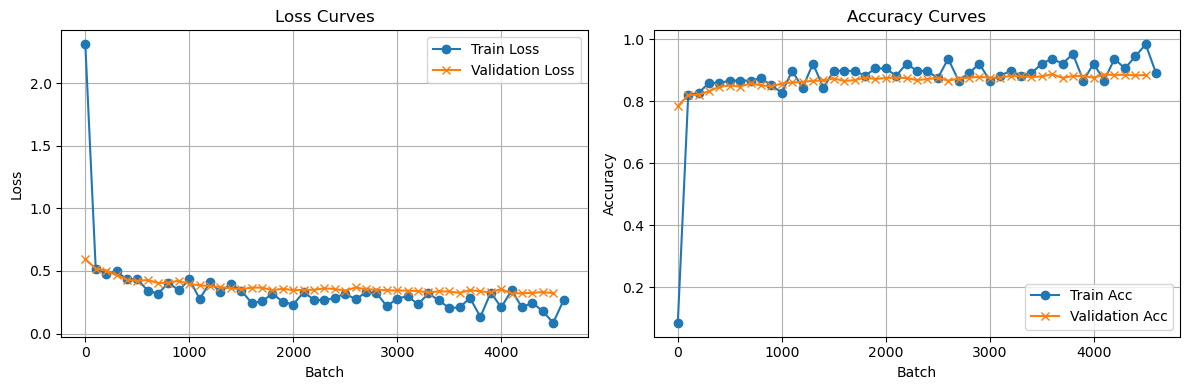

In [28]:
trainer.plot_curves()